<a href="https://colab.research.google.com/github/Anschoudary/PPE/blob/main/PPE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import time
import joblib
from tensorflow import keras
from keras.callbacks import ModelCheckpoint, CSVLogger
import warnings
warnings.filterwarnings("ignore")

In [3]:
%cd '/content/drive/MyDrive/CV_Projects/Construction_Site_Safety/'

/content/drive/MyDrive/CV_Projects/Construction_Site_Safety


In [4]:
!ls

PPE.ipynb


In [5]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="obF8OYUopQLjtQ5lkMUV")
project = rf.workspace("fire-djy6i").project("ppe-78f1t-e9hj5-zwrqy")
version = project.version(1)
dataset = version.download("yolov9")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.8 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PPE-1 in yolov9:: 100%|██████████| 969/969 [00:10<00:00, 96.81it/s]


In [6]:
%cd '/content/drive/MyDrive/CV_Projects'
!ls

/content/drive/MyDrive/CV_Projects
Construction_Site_Safety


In [7]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 901.7/901.7 kB 14.5 MB/s eta 0:00:00


In [8]:
!yolo task=detect mode=train model=yolov9s.pt data=/content/drive/MyDrive/CV_Projects/Construction_Site_Safety/PPE-1/data.yaml epochs=50 imgsz=224 plots=True

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
100% 14.7M/14.7M [00:00<00:00, 117MB/s] 
Ultralytics 8.3.52 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolov9s.pt, data=/content/drive/MyDrive/CV_Projects/Construction_Site_Safety/PPE-1/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=224, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0

In [9]:
!pwd
!ls runs/detect/

/content/drive/MyDrive/CV_Projects
train


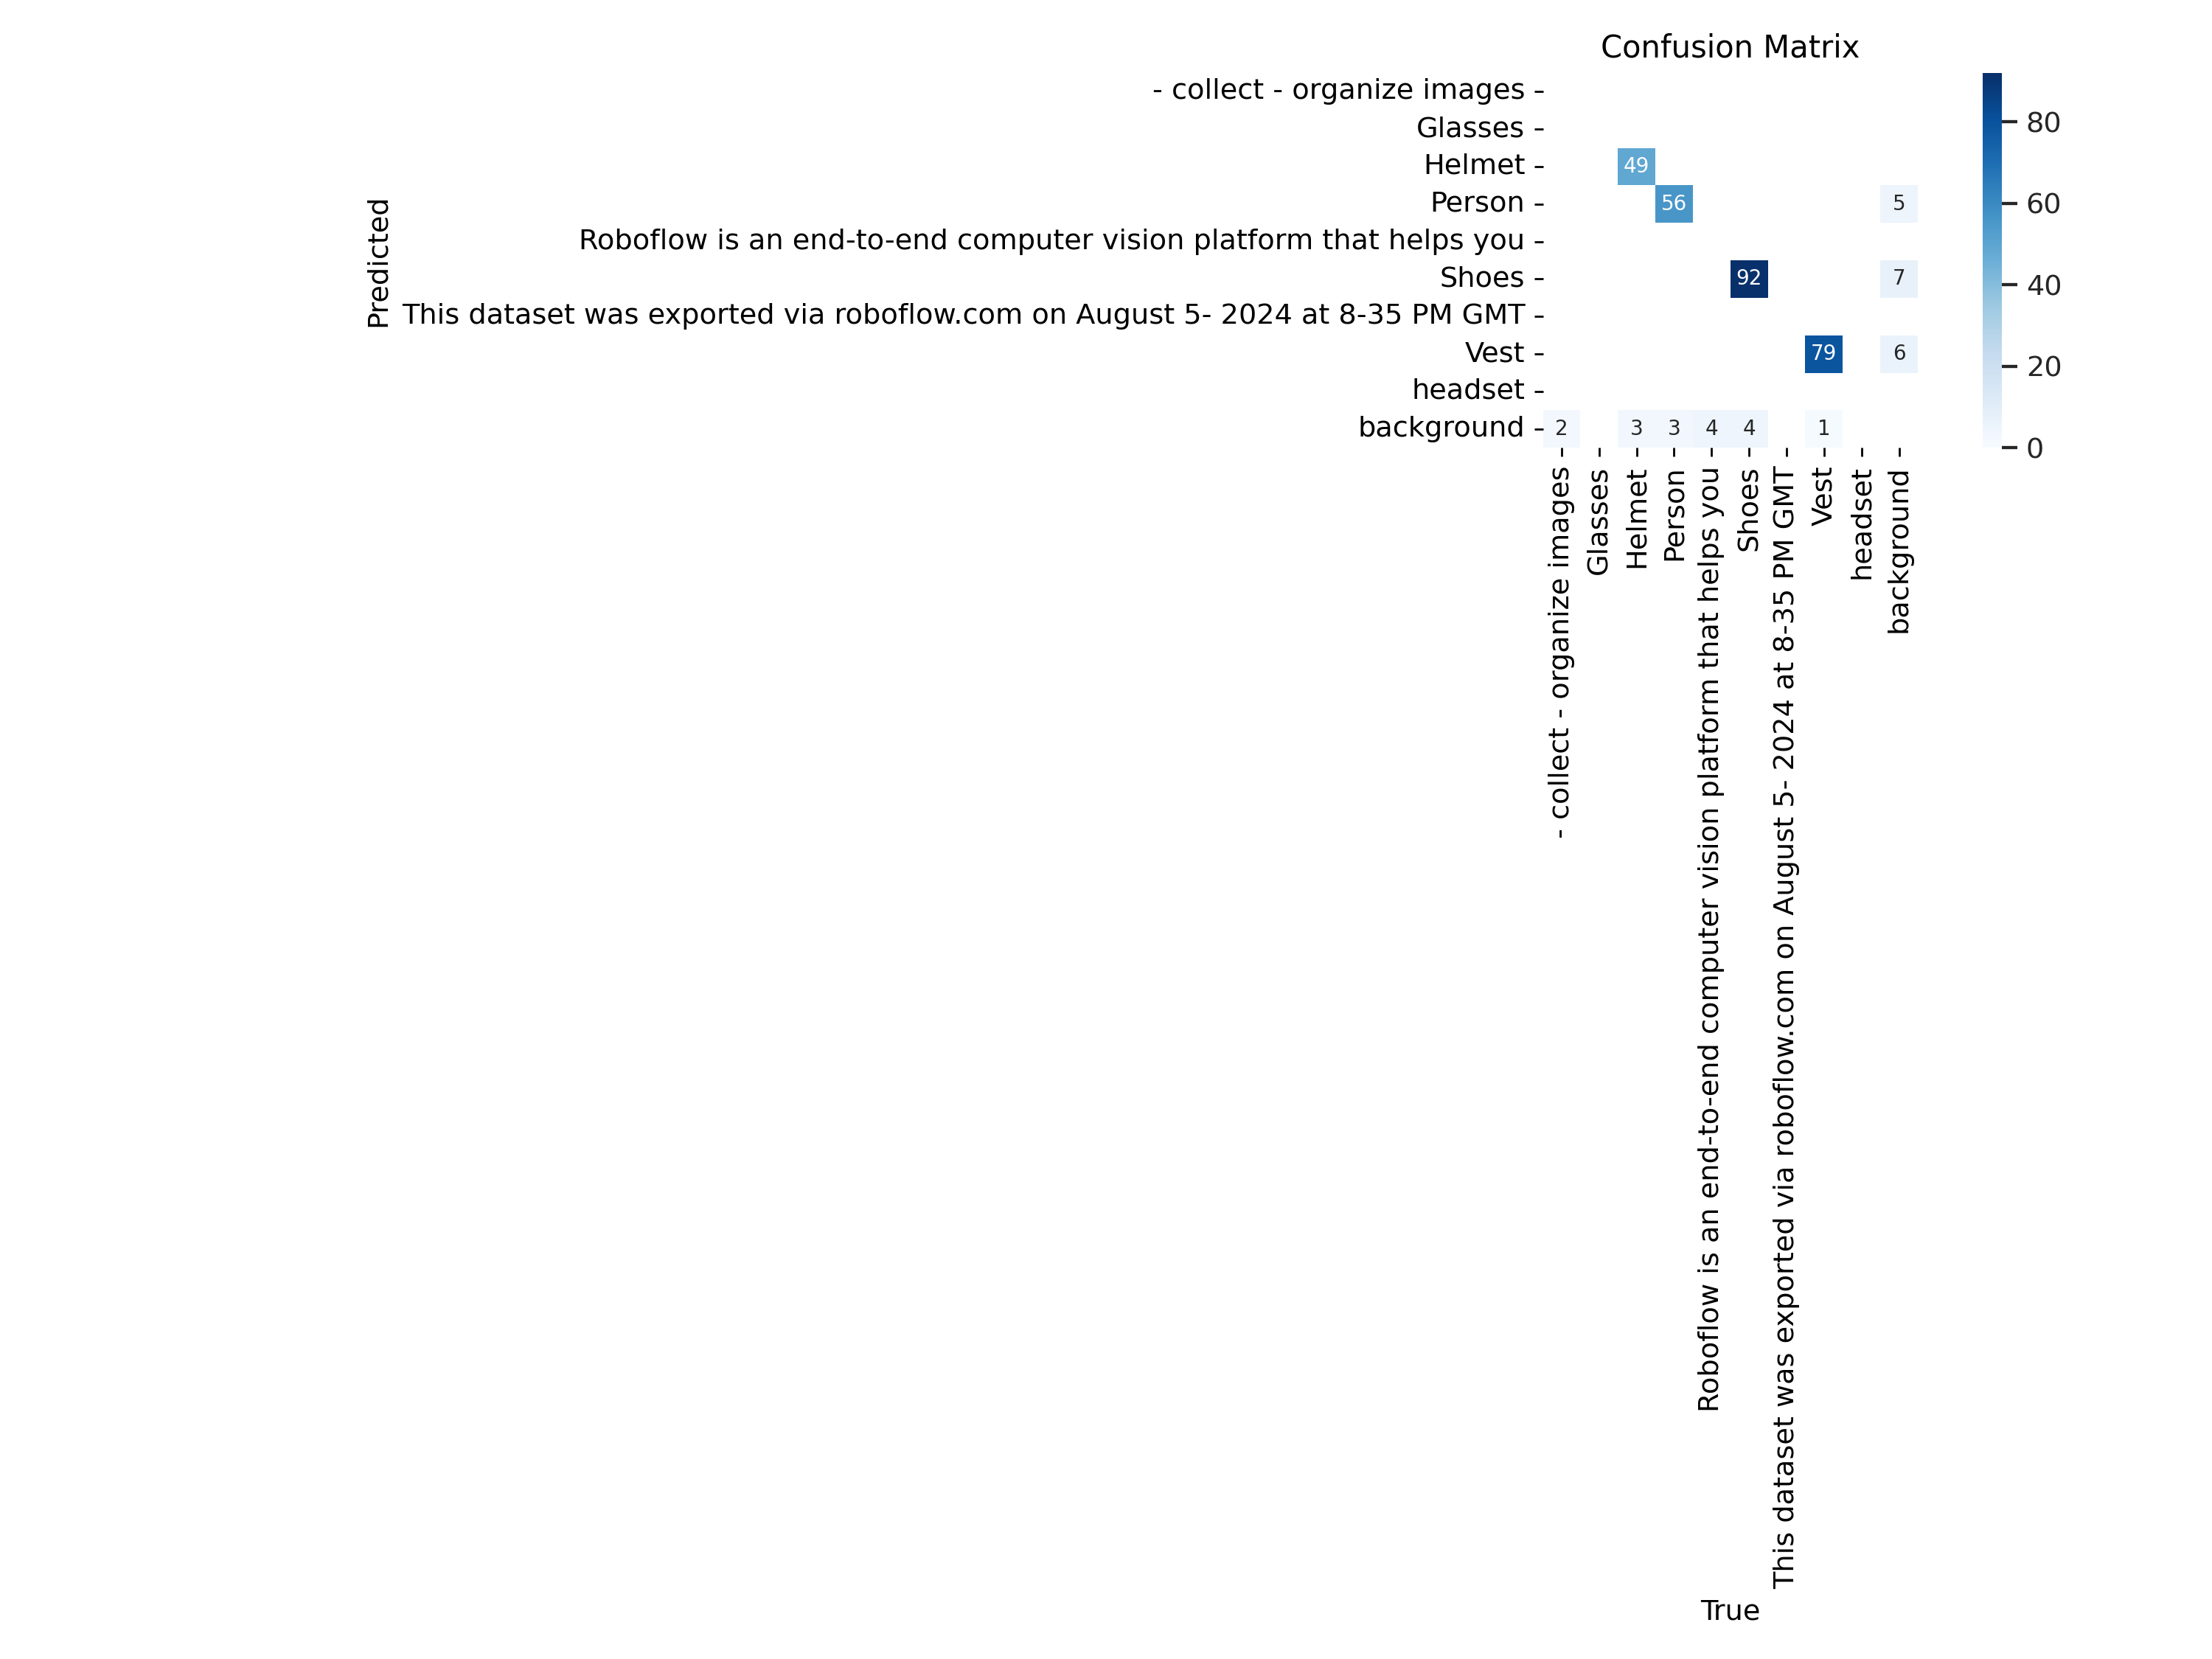

In [12]:
from IPython.display import Image
Image(filename='runs/detect/train/confusion_matrix.png', width=600)

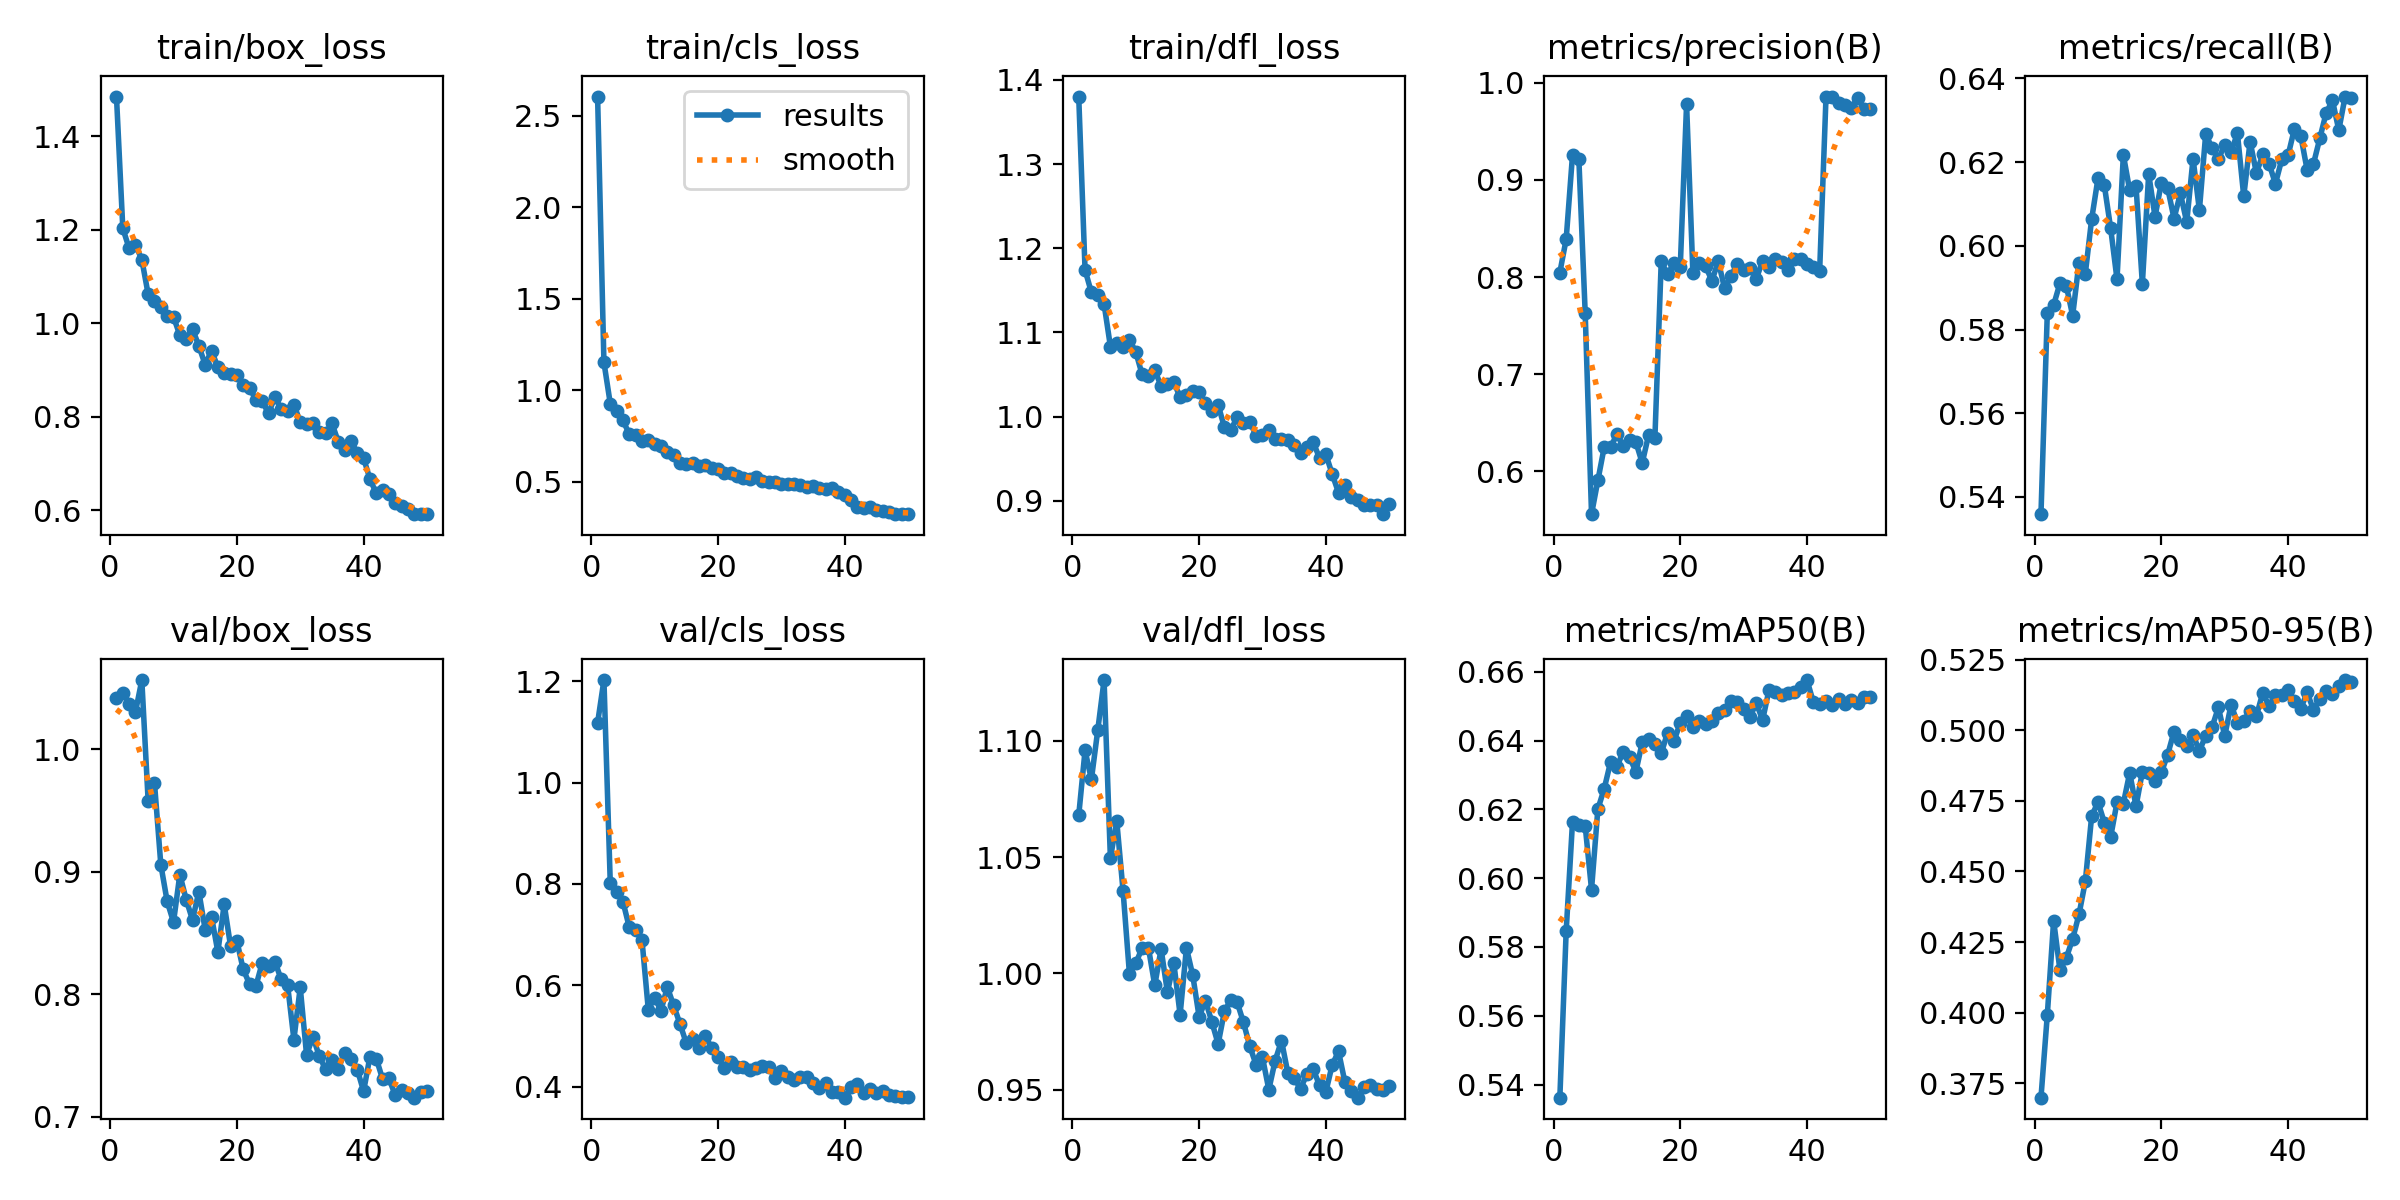

In [13]:
Image(filename='runs/detect/train/results.png', width=600)